In [1]:
from pathlib import Path
from src import config
import cv2
import numpy as np
from src.court_detector import CourtDetector
from src.utils.helpers import crop_center_img, load_process_params, lines_from_gray_img
from src.utils.filters import filter_horizontal_lines
from src.config import set_debug_mode, get_debug_mode
from cvgeomkit.utils.helpers import read_image_as_numpyimage, load_json
from cvgeomkit.utils.plotting import display_img
from cvgeomkit.geometry.intersections import compute_intersections
from cvgeomkit.geometry.lines import transform_line

In [2]:
get_debug_mode()
set_debug_mode(True)

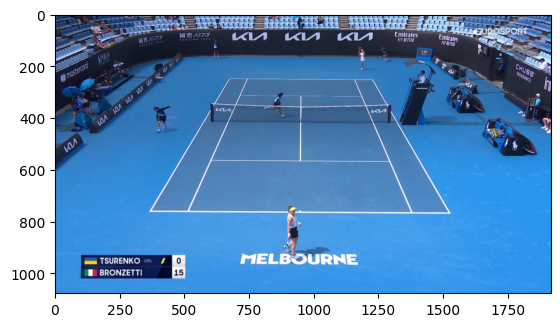

In [3]:
path = '../data/pics/01_01.png' # '../data/pics/05_10.png'     # '../data/pics/10_06.png'
# path = '../data/pics/skip/skip_01_35.png'
img = read_image_as_numpyimage(path)
display_img(img)

In [4]:
# roi = crop_center_img(img)[0][900:1000]  # [750:850]    # [900:1000]
# display_img(roi)

In [5]:
# out = cv2.bilateralFilter(roi, 15, 30, 30)
# display_img(out)

#### scan for baseline

In [6]:
params = load_process_params('../config/process_params.config.json')

crop_center_ratio = params.detection_params.basic.crop_center_ratio
roi_h_px = params.detection_params.basic.roi_h_px
step_px = params.detection_params.basic.step_px

warmup = params.detection_params.baseline.warmup
canny_lower_thresh = params.detection_params.baseline.canny_lower_thresh
canny_upper_thresh = params.detection_params.baseline.canny_upper_thresh
hough_thresh = params.detection_params.baseline.hough_thresh
min_line_len_ratio = params.detection_params.baseline.min_line_len_ratio
min_line_len_ensure_ratio = params.detection_params.baseline.min_line_len_ensure_ratio
min_line_gap_px = params.detection_params.baseline.min_line_gap_px
h_line_slope_tolerance = params.detection_params.baseline.h_line_slope_tolerance
h_delta_ensure_px = params.detection_params.baseline.h_delta_ensure_px

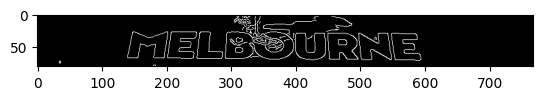

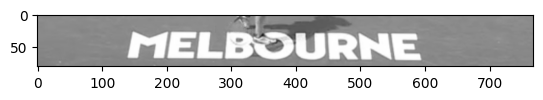

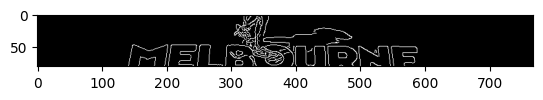

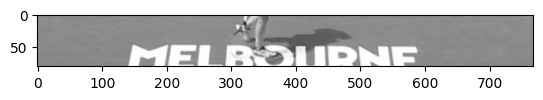

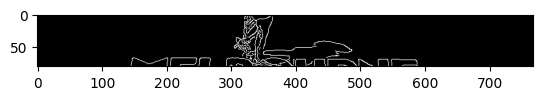

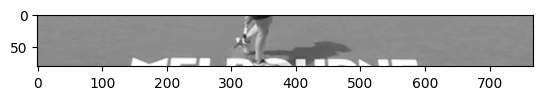

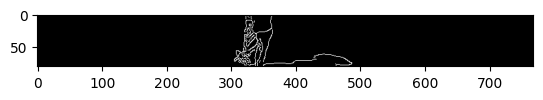

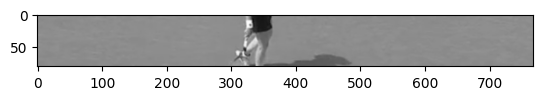

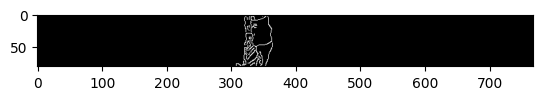

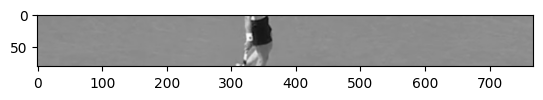

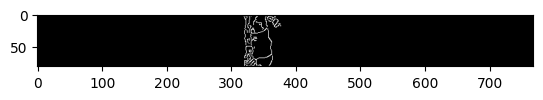

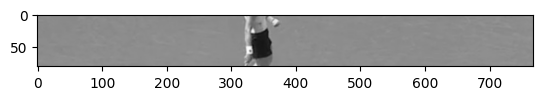

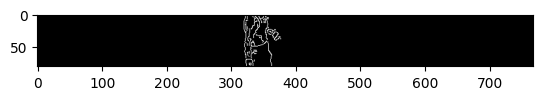

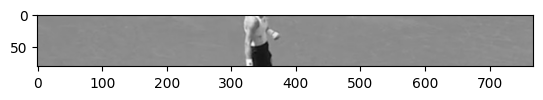

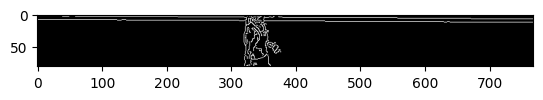

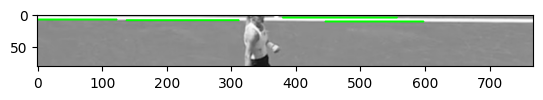

lines
[y = 0.0 * x + 9.0, y = 0.0 * x + 11.0, y = 0.0 * x + 8.0, y = 0.0 * x + 5.0]
baseline candidates
[y = 0.0 * x + 9.0, y = 0.0 * x + 11.0, y = 0.0 * x + 8.0, y = 0.0 * x + 5.0]


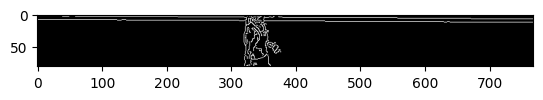

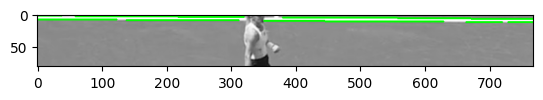

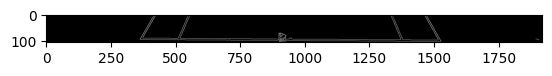

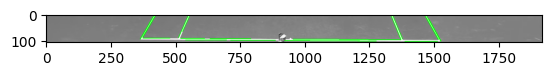

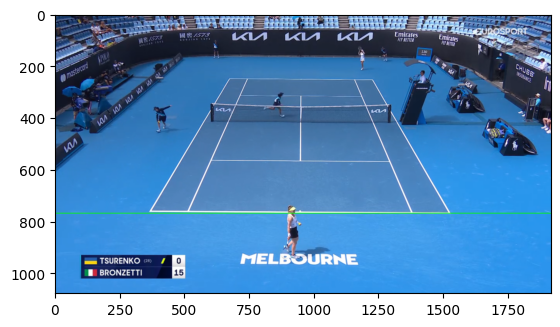

In [7]:
detector = CourtDetector(img, crop_center_ratio, roi_h_px, step_px)
baseline = detector.scan_for_baseline(
    warmup,
    canny_lower_thresh,
    canny_upper_thresh,
    hough_thresh,
    min_line_len_ratio,
    min_line_len_ensure_ratio,
    min_line_gap_px,
    h_line_slope_tolerance
)

if baseline is not None:
    p1, p2 = baseline.limit_to_img(img)
    img_copy = img.copy()
    cv2.line(img_copy, p1, p2, (0, 255, 0), 2)
    display_img(img_copy)

In [8]:
# baseline

In [9]:
delta = 100
h = 823 # int(baseline.intercept)
roi = img[h - delta:h+5] # img[h - delta:h + delta]

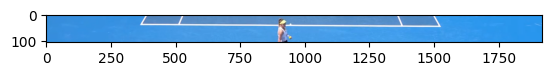

In [10]:
display_img(roi)

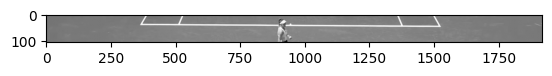

In [11]:
roi_gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
display_img(roi_gray)

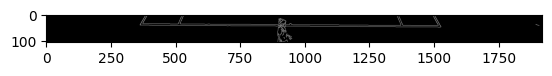

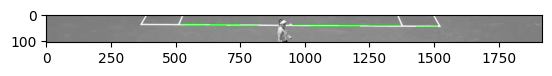

TypeError: 'NoneType' object is not iterable

In [12]:
lines = lines_from_gray_img(
    roi_gray, 
    100,
    200,
    50,
    0.03,
    5
)
lines = filter_horizontal_lines(lines, horizontal=False)
lines_global = [transform_line(line, roi, 0, h - delta) for line in lines]

In [ ]:
lines_global

[y = -0.03878326996197719 * x + 974.3475285171103,
 y = -0.04800872885979269 * x + 955.0327332242226,
 y = 0.04671857619577308 * x + 867.0,
 y = -0.05253399258343634 * x + 936.0,
 y = -0.043873729266987696 * x + 953.1059390048154,
 y = -0.054982817869415807 * x + 960.4020618556701,
 y = 0.06451612903225806 * x + 834.1612903225806,
 y = 0.02608242044861763 * x + 890.0,
 y = -0.018121911037891267 * x + 963.7397034596376,
 y = -0.024517475221700575 * x + 912.0,
 y = -0.01617110067814293 * x + 912.0,
 y = 0.028690662493479395 * x + 867.0,
 y = 0.02190923317683881 * x + 896.0,
 y = 0.05040214477211796 * x + 857.0,
 y = 0.01617110067814293 * x + 900.0,
 y = 0.05295566502463054 * x + 865.0,
 y = -0.03338549817423057 * x + 947.0,
 y = 0.0314502038439138 * x + 897.0,
 y = -0.028169014084507043 * x + 949.0,
 y = 0.039067422810333964 * x + 889.0,
 y = -0.06666666666666667 * x + 969.4,
 y = -0.023474178403755867 * x + 898.0,
 y = -0.08695652173913043 * x + 990.9130434782609,
 y = -0.02337398373983

177.77899543792572 (602, 951) y = 0.0 * x + 951.0 y = -0.03878326996197719 * x + 974.3475285171103 -2.2210045620742815 0.0
177.2514128429722 (84, 951) y = 0.0 * x + 951.0 y = -0.04800872885979269 * x + 955.0327332242226 -2.748587157027808 0.0
182.67483231996584 (1798, 951) y = 0.0 * x + 951.0 y = 0.04671857619577308 * x + 867.0 2.674832319965841 0.0
177.487831549404 (47, 951) y = 0.0 * x + 951.0 y = -0.043873729266987696 * x + 953.1059390048154 -2.512168450596007 0.0
176.85288539590638 (171, 951) y = 0.0 * x + 951.0 y = -0.054982817869415807 * x + 960.4020618556701 -3.1471146040936024 0.0
183.69138598645128 (1811, 951) y = 0.0 * x + 951.0 y = 0.06451612903225806 * x + 834.1612903225806 3.6913859864512757 0.0
178.96180461992034 (702, 951) y = 0.0 * x + 951.0 y = -0.018121911037891267 * x + 963.7397034596376 -1.038195380079648 0.0
182.8853885027497 (1865, 951) y = 0.0 * x + 951.0 y = 0.05040214477211796 * x + 857.0 2.8853885027496946 0.0
183.03130465805776 (1624, 951) y = 0.0 * x + 951.0

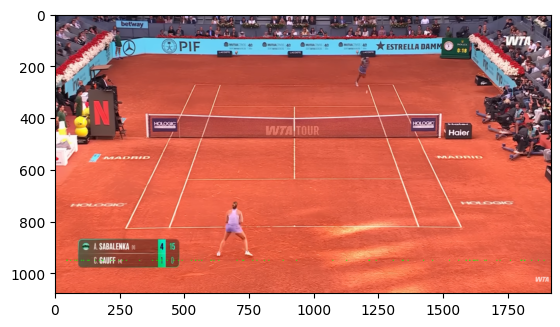

In [ ]:
img_copy = img.copy()
intersections = []
for line in lines_global:
    inter = baseline.intersection(line, img)
    if inter is None:
        continue
    intersections.append(inter)
    cv2.circle(img_copy, inter.point, 2, (0, 255, 0), -1)
    print(inter.angle, inter.point, inter.line1, inter.line2, line.theta, baseline.theta)

display_img(img_copy)

In [ ]:
inter_sorted = sorted(intersections, key = lambda inter: inter.point.x)
for inter in inter_sorted:
    print(inter.angle)

178.65527561129767
176.18845869564444
177.487831549404
177.37783369940206
177.79142568418771
177.37616987735115
177.2514128429722
176.82016988013578
177.8753834137315
178.081260989372
177.49791062290666
178.14715044841557
176.85288539590638
178.01937906313043
177.48747823597085
177.10737371265654
174.28940686250036
176.98180706363235
177.13242102864936
176.18592516570965
178.30790779428565
178.14040066125443
177.10759404121066
177.51044707800085
177.11103029992788
177.60456126764936
177.02976939280347
175.0302592718897
177.7714069573991
176.98932136178476
177.48899735808956
177.2499148250876
175.87882339246482
175.24030647489002
177.24344312846347
177.77899543792572
177.60317392494832
177.10253272394652
174.80557109226518
178.96180461992034
172.5621966968401
176.96697914995937
175.73800223701545
173.15451436112195
173.99099404250546
175.2363583092738
175.42388274226522
178.66101319452451
185.22334183018208
183.408256243406
182.8836424894865
182.21709837454992
180.97102193107918
183.723